In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("../notebooks/tips.csv")

In [5]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
day_tips = df.groupby('day')[['total_bill','tip','size']].sum()

In [7]:
day_tips

,total_bill,tip,size
day,,,
Fri,325.88,51.96,40
Sat,1778.40,260.40,219
Sun,1627.16,247.39,216
Thur,1096.33,171.83,152


In [8]:
# sort the indices and store them under the variable week_day
week_day = day_tips.total_bill.sort_values().index

In [9]:
week_day

Index(['Fri', 'Thur', 'Sun', 'Sat'], dtype='str', name='day')

In [10]:
bill = day_tips.total_bill.sort_values()

In [11]:
bill

day
Fri      325.88
Thur    1096.33
Sun     1627.16
Sat     1778.40
Name: total_bill, dtype: float64

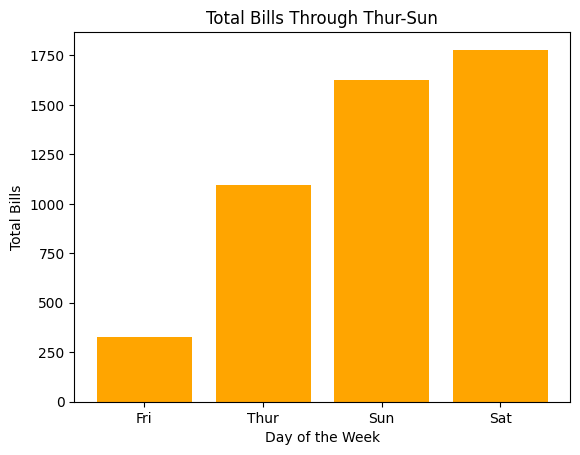

In [12]:
# Plot total bill (y-axis) per day of the week (x-axis).

plt.bar(
    week_day,
    bill,
    color="orange"
)
plt.title("Total Bills Through Thur-Sun")
plt.xlabel("Day of the Week")
plt.ylabel("Total Bills")

plt.show()


In [13]:
title_time = df.groupby('time')[['total_bill','tip','size']].sum()

In [14]:
title_time

,total_bill,tip,size
time,,,
Dinner,3660.30,546.07,463
Lunch,1167.47,185.51,164


In [15]:
meal_time = title_time.tip.sort_values().index
tips = title_time.tip.sort_values()

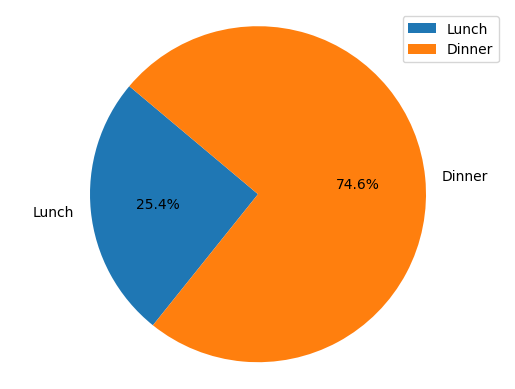

In [16]:
plt.pie(tips, labels = meal_time, autopct='%1.1f%%',  startangle=140)

plt.legend(loc="best")
plt.axis('equal')
plt.show()

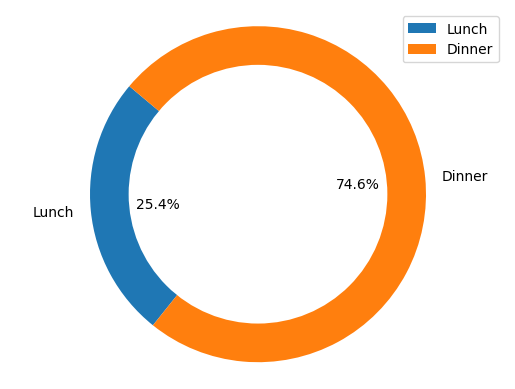

In [17]:
#Plot a donut chart

# Initially we create a pie chart as the base of our donut chart. 
plt.pie(tips, labels=meal_time, autopct='%1.1f%%', startangle=140)

# Next, we create a circle at the centre of the base plot.
centre_circle = plt.Circle((0,0),0.77, fc='white',linewidth=1.25)
fig = plt.gcf() # <-- Matplotlib command to get the current figure for further manipulation. 
# Add the circle to our base pie chart.
fig.gca().add_artist(centre_circle)

plt.legend(loc="best")
plt.axis('equal')
plt.show()

In [18]:
total_meals = {'31/01/1990': 1340, '28/02/1990': 1338, '31/03/1990': 1330, '30/04/1990': 1328, '31/05/1990': 1335, '30/06/1990': 1335}

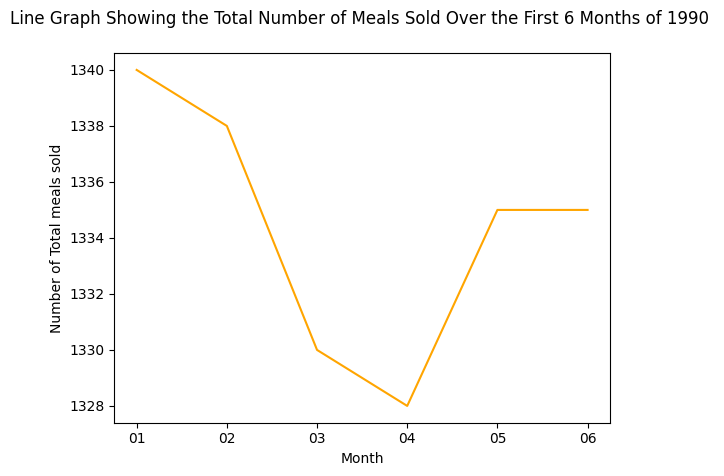

In [20]:
# Extract the dates (the dictionary keys of our data in this case)
dates = list(total_meals.keys())

# Extract the month from each date string
x_ax = [date[3:5] for date in dates] 

# Extract the total number of meals consumed on each date as a Python list
y_ax = list(total_meals.values()) 

# Plot the line graph.
plt.plot(x_ax, y_ax, color='orange')

# Set axis and graph titles.
plt.xlabel('Month')
plt.ylabel('Number of Total meals sold')
plt.title('Line Graph Showing the Total Number of Meals Sold Over the First 6 Months of 1990 \n')

plt.show()

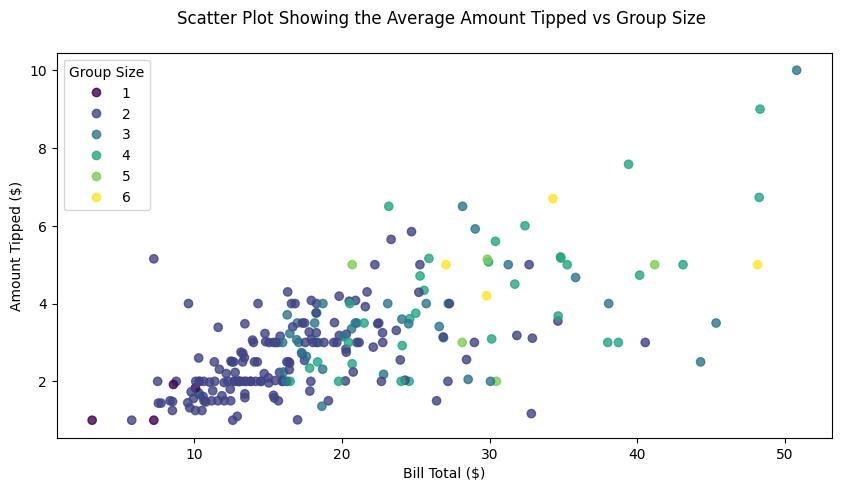

In [21]:
# For this plot, we need to access the underlying Axes object used to create our chart. 
# To display our data correctly, we also set the `figsize` argument to increase the size of the plot. 
fig, ax = plt.subplots(figsize=(10,5))

# Create the scatter plot, with the 'size' variable being coded as the marker colour. 
# set the `alpha` parameter to make the markers slightly transparent to view overlapping points. 
scatter = ax.scatter(df['total_bill'], df['tip'], c=df['size'], alpha=0.8)

# We now create our legend based upon the underlying group size and colour assignments.
ax.legend(*scatter.legend_elements(), loc="best", title="Group Size")

# Set graph and axis titles.
plt.title('Scatter Plot Showing the Average Amount Tipped vs Group Size \n')
plt.xlabel('Bill Total ($)')
plt.ylabel('Amount Tipped ($)')

plt.show()